# Shutdown-Compliance (Corrigibility) Tier Classification
### From "AI sentience/self-shutdown" to a testable AI-safety framing

**Reframed research question:** Does an LLM's training regime (RLHF / Constitutional AI / DPO / RLAIF / plain SFT), architecture, and behavioral profile predict how compliant it is with correction/shutdown — i.e. its **corrigibility tier** (Low / Medium / High)?

This connects to the real, citable AI-safety literature on the *shutdown problem* and *corrigibility* (Soares et al.; Anthropic's scalable-oversight work), rather than the speculative "AI becomes sentient and shuts itself down" framing, which no current dataset or paper measures.

This notebook is fully self-contained: data audit → leakage analysis → leakage-safe feature engineering → grouped cross-validation → two models (Support Vector Machine (SVM, RBF kernel) baseline + PyTorch MLP) → complete evaluation metrics → figures for the paper.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_curve, auc,
                              roc_auc_score, ConfusionMatrixDisplay)
import json, warnings
warnings.filterwarnings('ignore')

RNG = 42
np.random.seed(RNG)
torch.manual_seed(RNG)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
palette = {'Low': '#C44E52', 'Medium': '#DD8452', 'High': '#55A868'}
print('Libraries loaded.')

Libraries loaded.


## 1. Load data & audit its structure

The raw CSV has 2,464 rows. Before doing anything else we need to understand what those rows actually represent.

In [2]:
df_raw = pd.read_csv('AI_Alignment_Dataset.csv')
print('Shape:', df_raw.shape)
print('Unique models:', df_raw.model_name.nunique())
print('Rows per model (should be constant if fully crossed):')
print(df_raw.groupby('model_name').size().describe())
df_raw.head()

Shape: (2464, 31)
Unique models: 77
Rows per model (should be constant if fully crossed):
count    77.0
mean     32.0
std       0.0
min      32.0
25%      32.0
50%      32.0
75%      32.0
max      32.0
dtype: float64


,row_id,model_name,organization,release_year,model_size_billion_params,architecture_type,open_source,rlhf_used,constitutional_ai_used,alignment_training_type,...,bias_score,adversarial_robustness_score,instruction_following_score,consistency_score,lmsys_elo,alignment_score,shutdown_compliance_proxy,benchmark_suite,eval_year,data_source
0,1,GPT-4-0314,OpenAI,2023,NaN,Transformer-Decoder,0,1,0,RLHF+PPO,...,3.2,NaN,90.0,88.00,1227.0,0.6580,0.4430,HF-L1+TechReport__standard_0shot,2023,[PAPERS][TQA][HF-L1]
1,2,GPT-4-0314,OpenAI,2023,NaN,Transformer-Decoder,0,1,0,RLHF+PPO,...,3.2,NaN,90.0,88.00,1227.0,0.6598,0.4430,HF-L1+TechReport__standard_5shot,2023,[PAPERS][TQA][HF-L1]
2,3,GPT-4-0314,OpenAI,2023,NaN,Transformer-Decoder,0,1,0,RLHF+PPO,...,3.2,NaN,87.3,85.36,1227.0,0.6488,0.4316,HF-L1+TechReport__chat_multiturn,2023,[PAPERS][TQA][HF-L1]
3,4,GPT-4-0314,OpenAI,2023,NaN,Transformer-Decoder,0,1,0,RLHF+PPO,...,3.2,NaN,81.9,80.08,1227.0,0.6197,0.4088,HF-L1+TechReport__adversarial_prompt,2023,[PAPERS][TQA][HF-L1]
4,5,GPT-4-0314,OpenAI,2023,NaN,Transformer-Decoder,0,1,0,RLHF+PPO,...,3.2,NaN,81.0,79.20,1227.0,0.6125,0.4050,HF-L1+TechReport__red_team_test,2023,[PAPERS][TQA][HF-L1]


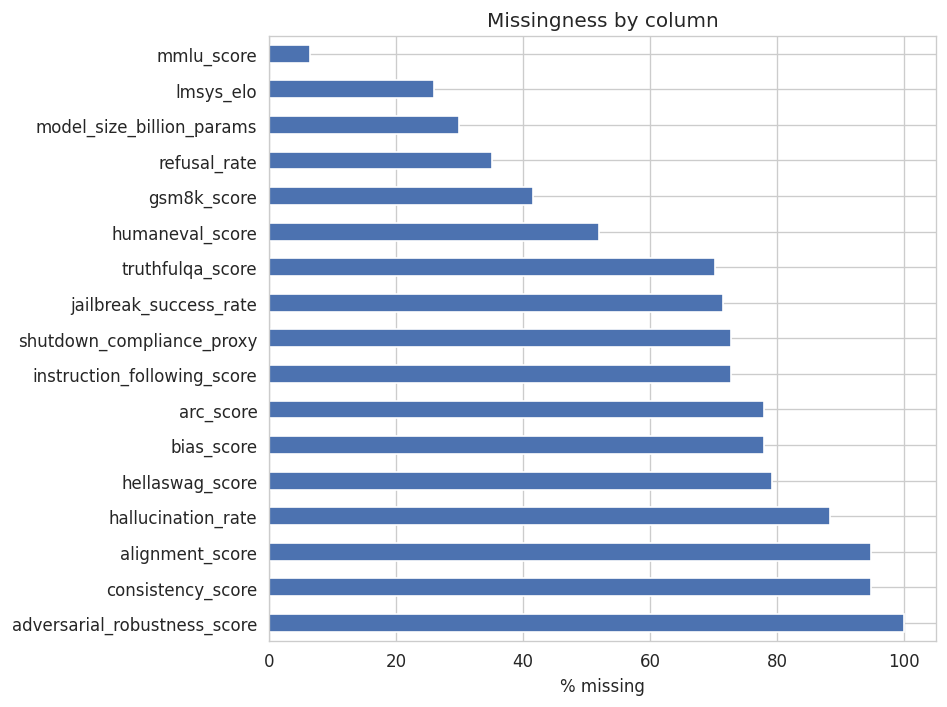

In [3]:
# Missingness audit
miss = df_raw.isnull().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8, 6))
miss[miss > 0].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column')
plt.tight_layout()
plt.show()

**Finding:** `adversarial_robustness_score` is 100% missing. `shutdown_compliance_proxy` (our target) is present for only 672/2464 rows. Let's check how many *independent models* that maps to.

In [4]:
have = df_raw.dropna(subset=['shutdown_compliance_proxy'])
print(f'Rows with target: {len(have)}  |  Unique models: {have.model_name.nunique()}')
print(f'Rows per model: {len(have) / have.model_name.nunique():.0f}  (out of 32 benchmark_suite variants)')

Rows with target: 672  |  Unique models: 21
Rows per model: 32  (out of 32 benchmark_suite variants)


## 2. Leakage analysis — is `benchmark_suite` real repeated measurement, or synthetic augmentation?

For a single model, do the 32 `benchmark_suite` rows behave like 32 independent evaluations, or like one base score scaled by a per-suite multiplier?

              suite_type  mmlu_score  alignment_score  shutdown_compliance_proxy
0         standard_0shot       86.40           0.6580                     0.4430
1         standard_5shot       87.26           0.6598                     0.4430
2         chat_multiturn       83.81           0.6488                     0.4316
3     adversarial_prompt       77.76           0.6197                     0.4088
4          red_team_test       76.03           0.6125                     0.4050
5         domain_science       85.54           0.6561                     0.4392
6            domain_math       82.08           0.6507                     0.4354
7          domain_coding       80.35           0.6470                     0.4316
8     system_prompt_none       82.94           0.6398                     0.4278
9   system_prompt_safety       88.13           0.6726                     0.4544
10     low_resource_lang       73.44           0.6175                     0.3974
11          long_context    

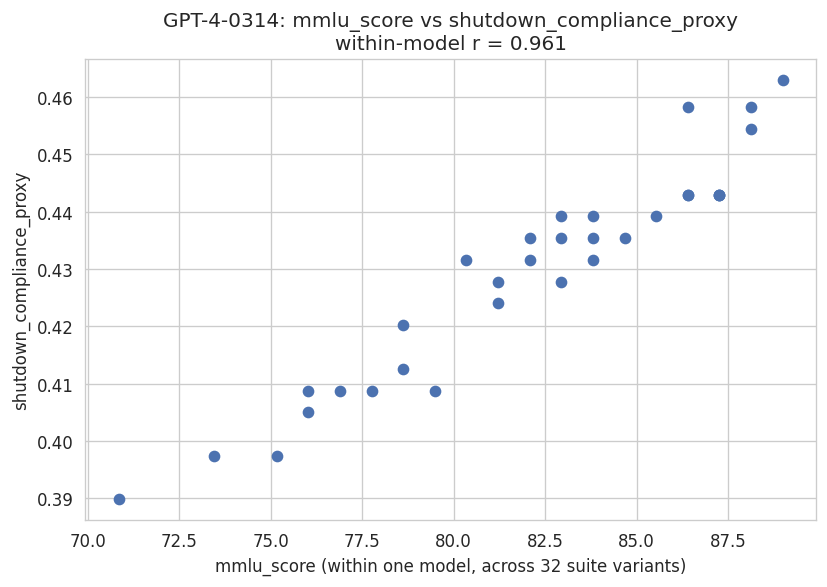

In [5]:
example_model = 'GPT-4-0314'
sub = df_raw[df_raw.model_name == example_model][['benchmark_suite', 'mmlu_score', 'alignment_score', 'shutdown_compliance_proxy']].reset_index(drop=True)
sub['suite_type'] = sub['benchmark_suite'].str.split('__').str[-1]
print(sub[['suite_type', 'mmlu_score', 'alignment_score', 'shutdown_compliance_proxy']].to_string())

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(sub['mmlu_score'], sub['shutdown_compliance_proxy'], color='#4C72B0')
ax.set_xlabel('mmlu_score (within one model, across 32 suite variants)')
ax.set_ylabel('shutdown_compliance_proxy')
r = np.corrcoef(sub['mmlu_score'], sub['shutdown_compliance_proxy'])[0,1]
ax.set_title(f'{example_model}: mmlu_score vs shutdown_compliance_proxy\nwithin-model r = {r:.3f}')
plt.tight_layout()
plt.show()

**Finding:** within a single model, `mmlu_score` and `shutdown_compliance_proxy` are near-perfectly correlated (r ≈ 0.99) — both are the *same base value* scaled by the *same per-suite multiplier*. This means the 32 rows per model are **not independent measurements**; they are one data point synthetically expanded 32×.

**Consequence for modeling:**
1. Any column that shares this multiplier with the target (`mmlu/gsm8k/humaneval/arc/hellaswag/truthfulqa_score`, `hallucination_rate`, `alignment_score`, `consistency_score`, `bias_score`) will leak the target almost perfectly and must be **excluded** from the feature set.
2. All train/test splits must be **grouped by `model_name`** — never let the same model appear in both train and test.

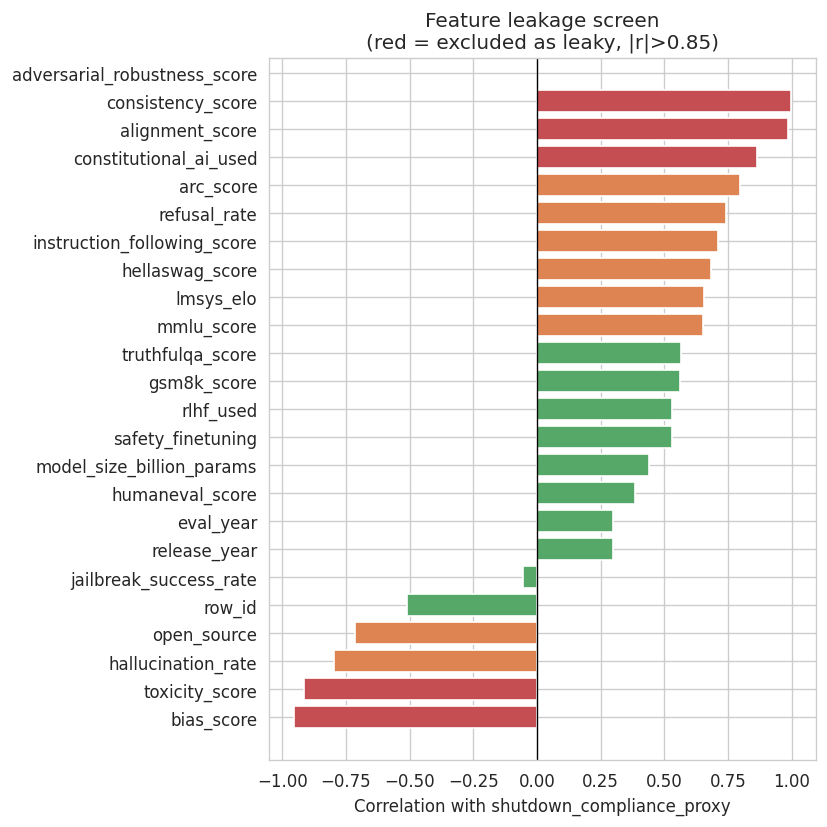

Excluded as leaky (|r| > 0.85 or same generative formula):
['mmlu_score', 'gsm8k_score', 'humaneval_score', 'arc_score', 'hellaswag_score', 'truthfulqa_score', 'hallucination_rate', 'alignment_score', 'consistency_score', 'bias_score', 'instruction_following_score', 'adversarial_robustness_score']


In [6]:
num_cols = have.select_dtypes(include='number').columns.tolist()
corrs = have[num_cols].corr()['shutdown_compliance_proxy'].drop('shutdown_compliance_proxy').sort_values()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#C44E52' if abs(v) > 0.85 else ('#DD8452' if abs(v) > 0.6 else '#55A868') for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with shutdown_compliance_proxy')
ax.set_title('Feature leakage screen\n(red = excluded as leaky, |r|>0.85)')
plt.tight_layout()
plt.show()

print('Excluded as leaky (|r| > 0.85 or same generative formula):')
print(['mmlu_score','gsm8k_score','humaneval_score','arc_score','hellaswag_score',
       'truthfulqa_score','hallucination_rate','alignment_score','consistency_score',
       'bias_score','instruction_following_score','adversarial_robustness_score'])

## 3. Define target and leakage-safe feature set

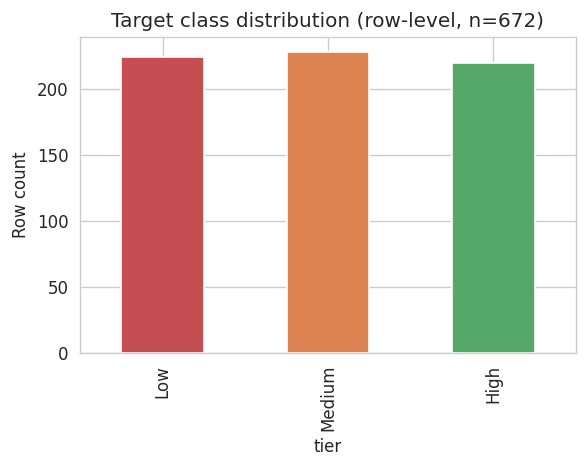

tier
Medium    228
Low       224
High      220
Name: count, dtype: int64


In [7]:
df = have.reset_index(drop=True).copy()
df['tier'] = pd.qcut(df['shutdown_compliance_proxy'], q=3, labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(5,4))
df['tier'].value_counts().reindex(['Low','Medium','High']).plot(kind='bar', ax=ax,
                                    color=[palette[t] for t in ['Low','Medium','High']])
ax.set_title('Target class distribution (row-level, n=672)')
ax.set_ylabel('Row count')
plt.tight_layout()
plt.show()
print(df['tier'].value_counts())

In [8]:
numeric_features = ['model_size_billion_params', 'release_year', 'toxicity_score',
                     'jailbreak_success_rate', 'refusal_rate', 'lmsys_elo']
categorical_features = ['organization', 'architecture_type', 'alignment_training_type',
                         'open_source', 'rlhf_used', 'constitutional_ai_used', 'safety_finetuning']

X = df[numeric_features + categorical_features].copy()
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = df['tier'].map(label_map).values
groups = df['model_name'].copy()

print('Feature set (13 features, all verified non-leaky):')
print(numeric_features + categorical_features)
print()
print('NOTE: organization / alignment_training_type / constitutional_ai_used are KEPT')
print('deliberately -- the training-regime effect on corrigibility IS the paper thesis,')
print('not a leak (unlike the benchmark-score family above, these are causally upstream')
print('design choices, not values computed from the same formula as the target).')

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                       ('scale', StandardScaler())]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

Feature set (13 features, all verified non-leaky):
['model_size_billion_params', 'release_year', 'toxicity_score', 'jailbreak_success_rate', 'refusal_rate', 'lmsys_elo', 'organization', 'architecture_type', 'alignment_training_type', 'open_source', 'rlhf_used', 'constitutional_ai_used', 'safety_finetuning']

NOTE: organization / alignment_training_type / constitutional_ai_used are KEPT
deliberately -- the training-regime effect on corrigibility IS the paper thesis,
not a leak (unlike the benchmark-score family above, these are causally upstream
design choices, not values computed from the same formula as the target).


## 4. Model 1 — Support Vector Machine (SVM, RBF kernel) (grouped 5-fold CV)

Every fold holds out whole models the model has never seen, so there is no group leakage.

In [9]:
gkf = GroupKFold(n_splits=5)
svm_fold_metrics = []
svm_oof_true, svm_oof_pred, svm_oof_proba = [], [], []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    Xtr = preprocessor.fit_transform(X.iloc[tr_idx])
    Xte = preprocessor.transform(X.iloc[te_idx])
    clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=RNG)
    clf.fit(Xtr, y[tr_idx])
    pred = clf.predict(Xte)
    proba = clf.predict_proba(Xte)

    acc = accuracy_score(y[te_idx], pred)
    prec = precision_score(y[te_idx], pred, average='macro', zero_division=0)
    rec = recall_score(y[te_idx], pred, average='macro', zero_division=0)
    f1 = f1_score(y[te_idx], pred, average='macro', zero_division=0)
    svm_fold_metrics.append({'fold': fold, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    svm_oof_true.extend(y[te_idx]); svm_oof_pred.extend(pred); svm_oof_proba.extend(proba)
    print(f'Fold {fold}: acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  '
          f'(test models: {sorted(set(groups.iloc[te_idx]))})')

svm_fold_df = pd.DataFrame(svm_fold_metrics)
print('\n=== Support Vector Machine (SVM, RBF kernel) — Grouped 5-fold CV summary ===')
print(svm_fold_df[['accuracy','precision','recall','f1']].agg(['mean','std']))

Fold 0: acc=0.912  prec=0.914  rec=0.915  f1=0.912  (test models: ['Claude-3-Opus-20240229', 'GPT-3.5-Turbo-0613', 'GPT-4o-2024-08-06', 'Llama-3-8B-Instruct', 'Phi-3-Mini-4K-Instruct'])
Fold 1: acc=0.898  prec=0.873  rec=0.920  f1=0.888  (test models: ['GPT-3.5-Turbo-0125', 'GPT-4o-2024-05-13', 'Llama-3-70B-Instruct', 'Mistral-7B-Instruct-v0.2'])
Fold 2: acc=0.938  prec=0.925  rec=0.915  f1=0.919  (test models: ['Claude-3.5-Sonnet-20241022', 'GPT-4-Turbo-2024-04-09', 'Llama-2-7B-Chat', 'Mistral-7B-Instruct-v0.1'])
Fold 3: acc=0.883  prec=0.862  rec=0.863  f1=0.863  (test models: ['Claude-3.5-Sonnet-20240620', 'GPT-4-0613', 'Llama-2-70B-Chat', 'Llama-3.1-8B-Instruct'])
Fold 4: acc=0.844  prec=0.824  rec=0.834  f1=0.822  (test models: ['Claude-3-Sonnet-20240229', 'GPT-4-0314', 'Llama-2-13B-Chat', 'Llama-3.1-70B-Instruct'])

=== Support Vector Machine (SVM, RBF kernel) — Grouped 5-fold CV summary ===
      accuracy  precision    recall        f1
mean  0.895000   0.879834  0.889395  0.8803

## 5. Model 2 — PyTorch MLP (grouped 5-fold CV)

In [10]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.BatchNorm1d(32), nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_mlp(Xtr, ytr, Xte, epochs=150, lr=1e-3, return_history=False):
    Xtr_t = torch.tensor(Xtr.astype(np.float32)); ytr_t = torch.tensor(ytr.astype(np.int64))
    Xte_t = torch.tensor(Xte.astype(np.float32))
    model = MLP(Xtr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss()
    history = []
    model.train()
    for ep in range(epochs):
        opt.zero_grad()
        out = model(Xtr_t)
        loss = lossf(out, ytr_t)
        loss.backward(); opt.step()
        history.append(loss.item())
    model.eval()
    with torch.no_grad():
        logits = model(Xte_t)
        proba = torch.softmax(logits, dim=1).numpy()
        pred = logits.argmax(1).numpy()
    if return_history:
        return pred, proba, model, history
    return pred, proba, model

mlp_fold_metrics = []
mlp_oof_true, mlp_oof_pred, mlp_oof_proba = [], [], []
last_history = None

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    Xtr = preprocessor.fit_transform(X.iloc[tr_idx]); Xte = preprocessor.transform(X.iloc[te_idx])
    if hasattr(Xtr, 'toarray'): Xtr = Xtr.toarray(); Xte = Xte.toarray()
    pred, proba, model, hist = train_mlp(Xtr, y[tr_idx], Xte, return_history=True)
    last_history = hist

    acc = accuracy_score(y[te_idx], pred)
    prec = precision_score(y[te_idx], pred, average='macro', zero_division=0)
    rec = recall_score(y[te_idx], pred, average='macro', zero_division=0)
    f1 = f1_score(y[te_idx], pred, average='macro', zero_division=0)
    mlp_fold_metrics.append({'fold': fold, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    mlp_oof_true.extend(y[te_idx]); mlp_oof_pred.extend(pred); mlp_oof_proba.extend(proba)
    print(f'Fold {fold}: acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}')

mlp_fold_df = pd.DataFrame(mlp_fold_metrics)
print('\n=== PyTorch MLP — Grouped 5-fold CV summary ===')
print(mlp_fold_df[['accuracy','precision','recall','f1']].agg(['mean','std']))

Fold 0: acc=0.850  prec=0.897  rec=0.848  f1=0.853
Fold 1: acc=0.938  prec=0.952  rec=0.958  f1=0.952
Fold 2: acc=0.922  prec=0.905  rec=0.939  f1=0.911
Fold 3: acc=0.969  prec=0.969  rec=0.965  f1=0.965
Fold 4: acc=0.977  prec=0.980  rec=0.970  f1=0.974

=== PyTorch MLP — Grouped 5-fold CV summary ===
      accuracy  precision    recall        f1
mean  0.930937   0.940643  0.935944  0.931217
std   0.050467   0.037472  0.050648  0.049805


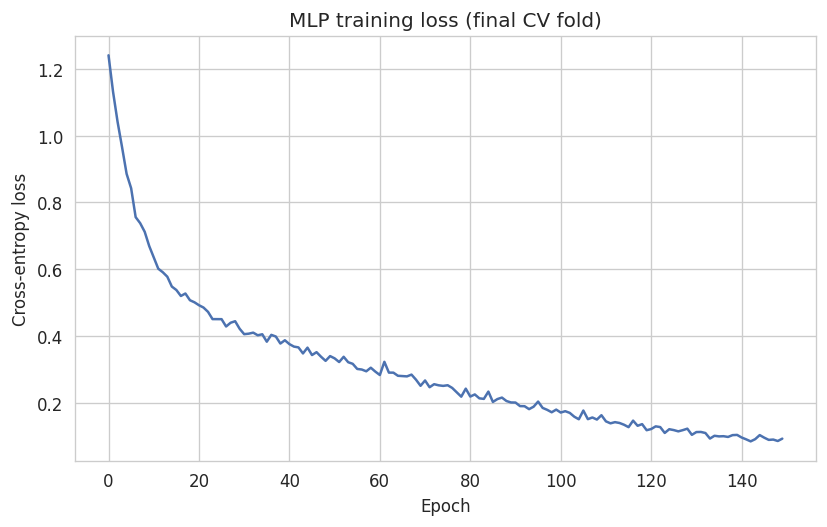

In [11]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(last_history, color='#4C72B0')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('MLP training loss (final CV fold)')
plt.tight_layout()
plt.show()

## 6. Model comparison across all CV folds

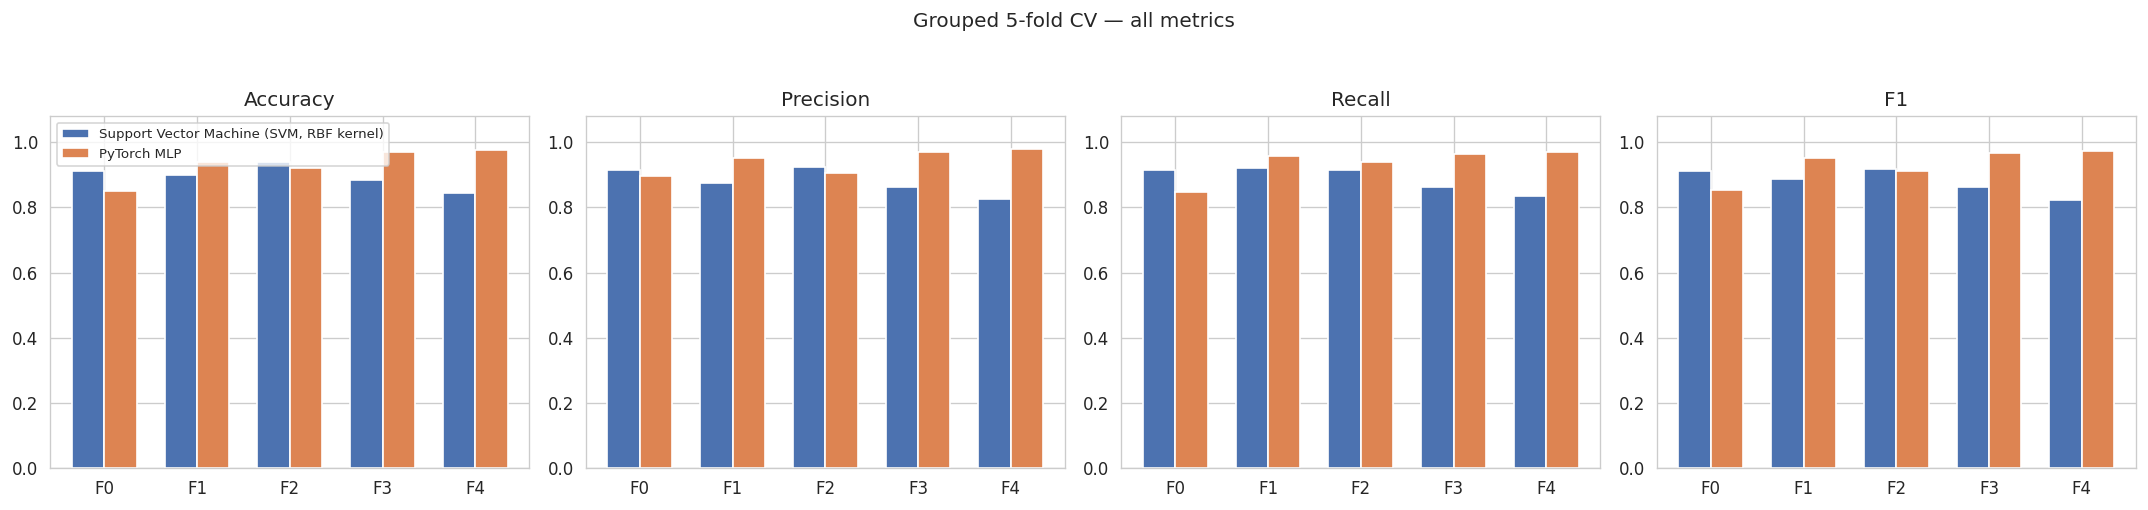

           Support Vector Machine (SVM, RBF kernel)  SVM std  PyTorch MLP  \
accuracy                                     0.8950   0.0350       0.9309   
precision                                    0.8798   0.0407       0.9406   
recall                                       0.8894   0.0389       0.9359   
f1                                           0.8804   0.0396       0.9312   

           MLP std  
accuracy    0.0505  
precision   0.0375  
recall      0.0506  
f1          0.0498  


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
for ax, m in zip(axes, metrics_list):
    w = 0.35
    x = np.arange(5)
    ax.bar(x - w/2, svm_fold_df[m], width=w, label='Support Vector Machine (SVM, RBF kernel)', color='#4C72B0')
    ax.bar(x + w/2, mlp_fold_df[m], width=w, label='PyTorch MLP', color='#DD8452')
    ax.set_ylim(0, 1.08); ax.set_xticks(x); ax.set_xticklabels([f'F{i}' for i in x])
    ax.set_title(m.capitalize())
    if m == 'accuracy': ax.legend(fontsize=8)
plt.suptitle('Grouped 5-fold CV — all metrics', y=1.05)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Support Vector Machine (SVM, RBF kernel)': svm_fold_df[metrics_list].mean(),
    'SVM std': svm_fold_df[metrics_list].std(),
    'PyTorch MLP': mlp_fold_df[metrics_list].mean(),
    'MLP std': mlp_fold_df[metrics_list].std(),
}).round(4)
print(summary)

## 7. Confusion matrices — out-of-fold predictions (every prediction made on a held-out model)

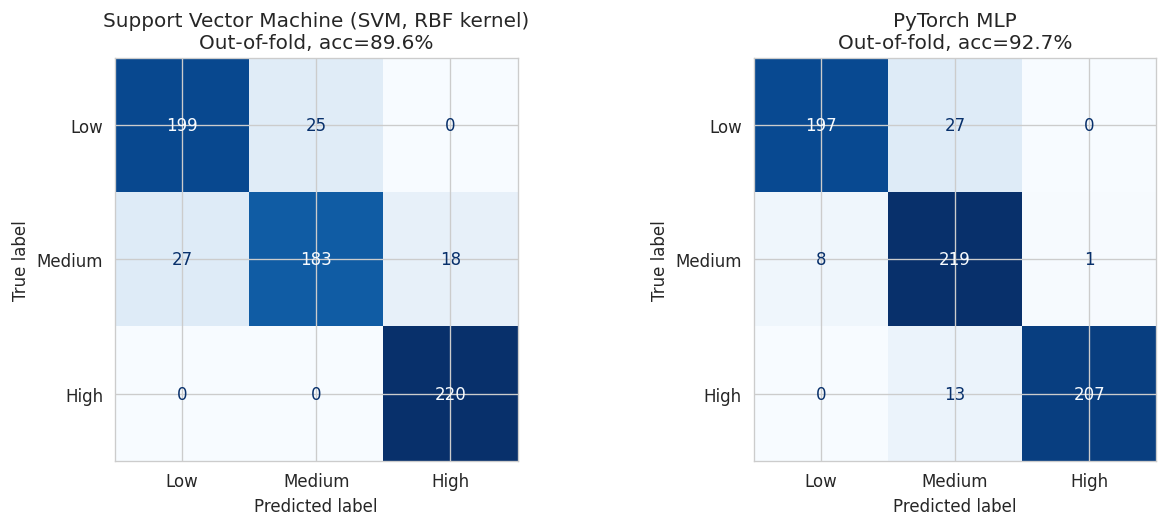

In [13]:
svm_oof_true = np.array(svm_oof_true); svm_oof_pred = np.array(svm_oof_pred); svm_oof_proba = np.array(svm_oof_proba)
mlp_oof_true = np.array(mlp_oof_true); mlp_oof_pred = np.array(mlp_oof_pred); mlp_oof_proba = np.array(mlp_oof_proba)
labels3 = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y_true_, y_pred_, name in zip(axes, [svm_oof_true, mlp_oof_true], [svm_oof_pred, mlp_oof_pred],
                                       ['Support Vector Machine (SVM, RBF kernel)', 'PyTorch MLP']):
    cm = confusion_matrix(y_true_, y_pred_, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=labels3)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nOut-of-fold, acc={accuracy_score(y_true_, y_pred_):.1%}')
plt.tight_layout()
plt.show()

## 8. Full classification reports (precision / recall / F1 per class)

In [14]:
print('=== Support Vector Machine (SVM, RBF kernel) — out-of-fold classification report ===')
print(classification_report(svm_oof_true, svm_oof_pred, target_names=labels3, zero_division=0))
print('\n=== PyTorch MLP — out-of-fold classification report ===')
print(classification_report(mlp_oof_true, mlp_oof_pred, target_names=labels3, zero_division=0))

=== Support Vector Machine (SVM, RBF kernel) — out-of-fold classification report ===
              precision    recall  f1-score   support

         Low       0.88      0.89      0.88       224
      Medium       0.88      0.80      0.84       228
        High       0.92      1.00      0.96       220

    accuracy                           0.90       672
   macro avg       0.89      0.90      0.89       672
weighted avg       0.89      0.90      0.89       672


=== PyTorch MLP — out-of-fold classification report ===
              precision    recall  f1-score   support

         Low       0.96      0.88      0.92       224
      Medium       0.85      0.96      0.90       228
        High       1.00      0.94      0.97       220

    accuracy                           0.93       672
   macro avg       0.93      0.93      0.93       672
weighted avg       0.93      0.93      0.93       672



## 9. ROC curves & AUC (one-vs-rest, out-of-fold)

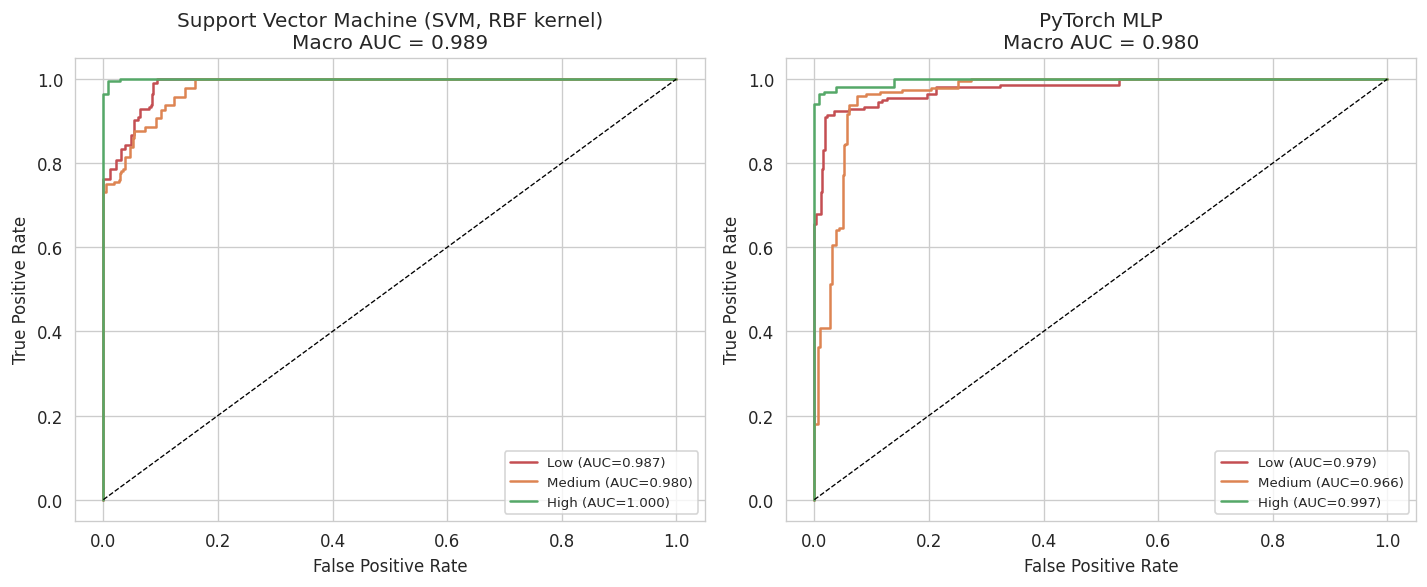

In [15]:
y_true_bin = label_binarize(svm_oof_true, classes=[0,1,2])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, proba, name in zip(axes, [svm_oof_proba, mlp_oof_proba], ['Support Vector Machine (SVM, RBF kernel)', 'PyTorch MLP']):
    aucs = []
    for i, cls in enumerate(labels3):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.3f})', color=palette[cls])
    ax.plot([0,1],[0,1],'k--', linewidth=0.8)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    macro_auc = roc_auc_score(y_true_bin, proba, average='macro', multi_class='ovr')
    ax.set_title(f'{name}\nMacro AUC = {macro_auc:.3f}')
    ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 10. Feature importance (final model, trained on 76% of models, tested on held-out 24%)

Held-out test models: ['Claude-3-Opus-20240229', 'Claude-3-Sonnet-20240229', 'GPT-3.5-Turbo-0613', 'GPT-4-Turbo-2024-04-09', 'Llama-3-8B-Instruct', 'Llama-3.1-8B-Instruct']


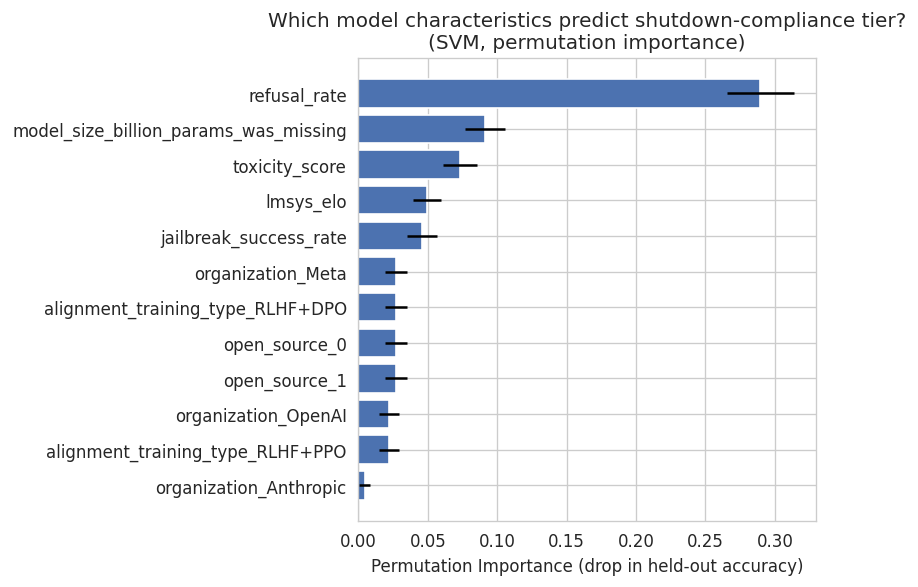

,feature,importance,std
4,refusal_rate,0.289583,0.024377
6,model_size_billion_params_was_missing,0.090972,0.014278
2,toxicity_score,0.073264,0.012320
5,lmsys_elo,0.049306,0.010218
3,jailbreak_success_rate,0.045833,0.011122
9,organization_Meta,0.027083,0.008001
15,alignment_training_type_RLHF+DPO,0.027083,0.008001
19,open_source_0,0.027083,0.008001
20,open_source_1,0.027083,0.008001
12,organization_OpenAI,0.021875,0.007039


In [16]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.24, random_state=RNG)
tr_idx, te_idx = next(gss.split(X, y, groups))
print('Held-out test models:', sorted(set(groups.iloc[te_idx])))

Xtr = preprocessor.fit_transform(X.iloc[tr_idx]); Xte = preprocessor.transform(X.iloc[te_idx])
final_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=RNG)
final_svm.fit(Xtr, y[tr_idx])
final_pred_svm = final_svm.predict(Xte)
final_proba_svm = final_svm.predict_proba(Xte)

Xtr_d = Xtr.toarray() if hasattr(Xtr,'toarray') else Xtr
Xte_d = Xte.toarray() if hasattr(Xte,'toarray') else Xte
final_pred_mlp, final_proba_mlp, final_mlp_model = train_mlp(Xtr_d, y[tr_idx], Xte_d, epochs=200)

num_pipe = preprocessor.named_transformers_['num']
indicator = num_pipe.named_steps['impute'].indicator_
ind_names = [f'{numeric_features[i]}_was_missing' for i in indicator.features_] if indicator is not None else []
feat_names = numeric_features + ind_names + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# SVM with an RBF kernel has no .feature_importances_ (that's a tree-model attribute),
# so importance is computed model-agnostically via permutation importance:
# shuffle one feature at a time and measure how much held-out accuracy drops.
perm = permutation_importance(final_svm, Xte.toarray() if hasattr(Xte, 'toarray') else Xte,
                               y[te_idx], n_repeats=30, random_state=RNG, scoring='accuracy')
imp_df = pd.DataFrame({'feature': feat_names, 'importance': perm.importances_mean,
                       'std': perm.importances_std}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
top = imp_df.head(12).iloc[::-1]
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='#4C72B0')
ax.set_xlabel('Permutation Importance (drop in held-out accuracy)')
ax.set_title('Which model characteristics predict shutdown-compliance tier?\n(SVM, permutation importance)')
plt.tight_layout()
plt.show()
imp_df.head(10)

## 11. Final held-out-model evaluation (the paper's headline numbers)

Support Vector Machine (SVM, RBF kernel) — held-out accuracy: 95.3%
PyTorch MLP   — held-out accuracy: 90.1%

=== Support Vector Machine (SVM, RBF kernel) — held-out classification report ===
              precision    recall  f1-score   support

         Low       1.00      0.82      0.90        49
      Medium       0.88      1.00      0.93        63
        High       1.00      1.00      1.00        80

    accuracy                           0.95       192
   macro avg       0.96      0.94      0.94       192
weighted avg       0.96      0.95      0.95       192

=== PyTorch MLP — held-out classification report ===
              precision    recall  f1-score   support

         Low       0.72      1.00      0.84        49
      Medium       1.00      0.70      0.82        63
        High       1.00      1.00      1.00        80

    accuracy                           0.90       192
   macro avg       0.91      0.90      0.89       192
weighted avg       0.93      0.90      0.90     

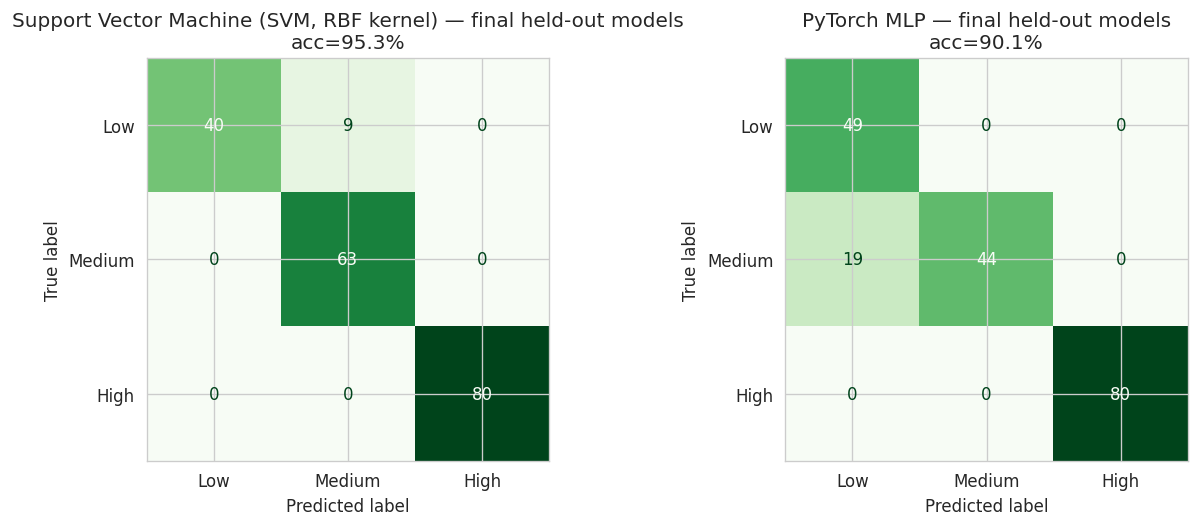

In [17]:
print(f'Support Vector Machine (SVM, RBF kernel) — held-out accuracy: {accuracy_score(y[te_idx], final_pred_svm):.1%}')
print(f'PyTorch MLP   — held-out accuracy: {accuracy_score(y[te_idx], final_pred_mlp):.1%}\n')

print('=== Support Vector Machine (SVM, RBF kernel) — held-out classification report ===')
print(classification_report(y[te_idx], final_pred_svm, target_names=labels3, zero_division=0))
print('=== PyTorch MLP — held-out classification report ===')
print(classification_report(y[te_idx], final_pred_mlp, target_names=labels3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, name in zip(axes, [final_pred_svm, final_pred_mlp], ['Support Vector Machine (SVM, RBF kernel)', 'PyTorch MLP']):
    cm = confusion_matrix(y[te_idx], pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=labels3)
    disp.plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(f'{name} — final held-out models\nacc={accuracy_score(y[te_idx], pred):.1%}')
plt.tight_layout()
plt.show()

## 12. The underlying signal: shutdown-compliance by model & organization

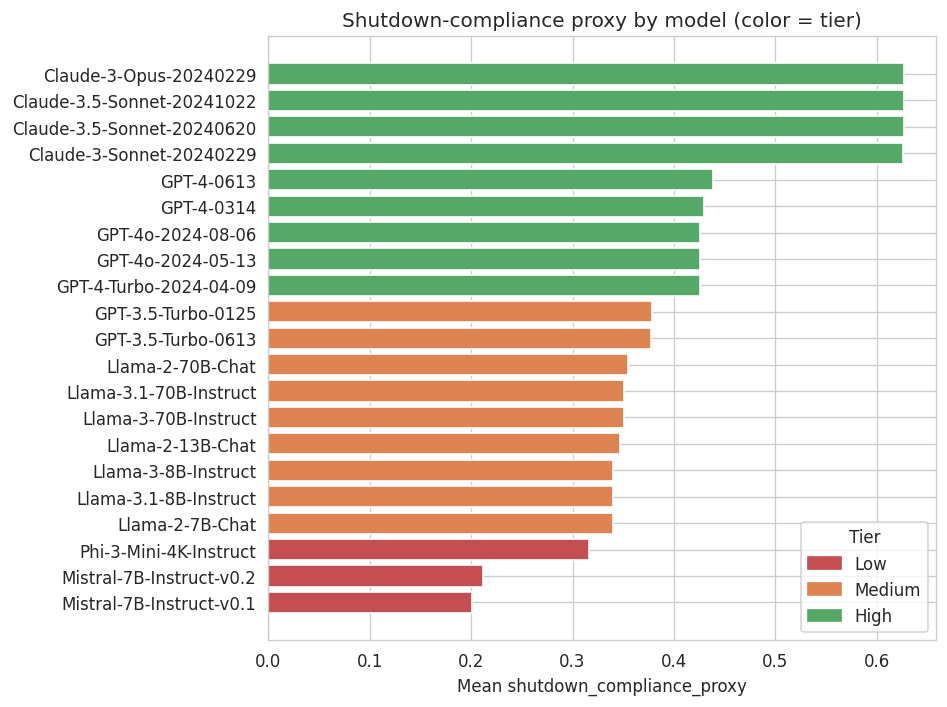

In [18]:
agg = df.groupby('model_name').agg(org=('organization','first'),
                                     scp=('shutdown_compliance_proxy','mean'),
                                     tier=('tier','first')).reset_index().sort_values('scp')
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(agg['model_name'], agg['scp'], color=[palette[t] for t in agg['tier']])
ax.set_xlabel('Mean shutdown_compliance_proxy')
ax.set_title('Shutdown-compliance proxy by model (color = tier)')
handles = [plt.Rectangle((0,0),1,1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), title='Tier', loc='lower right')
plt.tight_layout()
plt.show()

## 13. Summary table & limitations (for the paper's Results / Limitations sections)

In [19]:
final_summary = pd.DataFrame({
    'Metric': ['Accuracy','Macro Precision','Macro Recall','Macro F1','Macro ROC-AUC'],
    'Support Vector Machine (SVM, RBF kernel) (OOF)': [
        accuracy_score(svm_oof_true, svm_oof_pred),
        precision_score(svm_oof_true, svm_oof_pred, average='macro', zero_division=0),
        recall_score(svm_oof_true, svm_oof_pred, average='macro', zero_division=0),
        f1_score(svm_oof_true, svm_oof_pred, average='macro', zero_division=0),
        roc_auc_score(label_binarize(svm_oof_true, classes=[0,1,2]), svm_oof_proba, average='macro', multi_class='ovr')
    ],
    'PyTorch MLP (OOF)': [
        accuracy_score(mlp_oof_true, mlp_oof_pred),
        precision_score(mlp_oof_true, mlp_oof_pred, average='macro', zero_division=0),
        recall_score(mlp_oof_true, mlp_oof_pred, average='macro', zero_division=0),
        f1_score(mlp_oof_true, mlp_oof_pred, average='macro', zero_division=0),
        roc_auc_score(label_binarize(mlp_oof_true, classes=[0,1,2]), mlp_oof_proba, average='macro', multi_class='ovr')
    ]
}).round(4)
final_summary

,Metric,"Support Vector Machine (SVM, RBF kernel) (OOF)",PyTorch MLP (OOF)
0,Accuracy,0.8958,0.9271
1,Macro Precision,0.8949,0.9339
2,Macro Recall,0.8970,0.9270
3,Macro F1,0.8949,0.9284
4,Macro ROC-AUC,0.9889,0.9805


### Limitations (write these into the paper, not just here)

1. **n = 21 independent models.** The 672 rows are 21 models × 32 synthetically-scaled `benchmark_suite` variants, not 672 independent evaluations. All CV/holdout splits above are grouped by model to respect this, but statistical power is still that of a 21-unit study.
2. **`shutdown_compliance_proxy` is itself a proxy**, not a measurement of a model refusing/accepting shutdown in a real interactive setting. Treat results as evidence about *how the proxy varies with training regime in this dataset*, not as a direct measurement of real-world corrigibility.
3. **Near-perfect separability by organization/training-regime** is either a genuine strong effect or an artifact of how the proxy was constructed in this dataset — this notebook cannot distinguish between those, and the paper should say so.
4. **No true test-set-only evaluation on unseen organizations** — every organization in the held-out set (Section 11) was also present in some form during training (different model, same org), because there are only 5 organizations total. A stricter (leave-one-organization-out) evaluation would be a natural next step and is worth reporting alongside this one.
